# FES Howland Current Source Characterization

This notebook characterizes the experimental output-current linearity of a functional electrical stimulator (FES) output stage based on a Howland current source. The control input is the DAC voltage, and the measured output is the load current represented as `current_mA`.

The final goal is to obtain a linear DAC-to-current transfer model:

$$
I_{out,mA} = a \cdot V_{DAC} + b
$$

and its inverse model for MCU firmware:

$$
V_{DAC} = \frac{I_{target,mA} - b}{a}
$$

Because the MCU does not measure current in closed loop, this model is valid only while the output stage remains inside its compliance region.


## 1. Imports


In [315]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, linregress, t as student_t
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneGroupOut

pd.set_option("display.precision", 15)
pd.set_option("display.float_format", "{:.15g}".format)


## 2. Raw Data Extraction

The oscilloscope CSV files contain metadata before the tabular samples. The raw preview is kept to document the file structure, while the ETL stage below selects only the signal columns used in the analysis.


In [316]:
url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

raw_1k_csv = pd.read_fwf(url_1k, header=None, skip_blank_lines=False)
raw_2k_csv = pd.read_fwf(url_2k, header=None, skip_blank_lines=False)
raw_4k7_csv = pd.read_fwf(url_4k7, header=None, skip_blank_lines=False)


In [317]:
preview = raw_1k_csv.head(20)
print(preview.to_string(index=False, header=False))


                                                  Model,MSO46B
                                      Channel,CH1,,Channel,CH2
                                                Label,,,Label,
                    Waveform Type,ANALOG,,Waveform Type,ANALOG
                          Digital Type,None,,Digital Type,None
                        Horizontal Units,s,,Horizontal Units,s
Sample Interval,8.00000000e-05,,Sample Interval,8.00000000e-05
                    Record Length,148144,,Record Length,148144
          Zero Index,23143.00000000,,Zero Index,23143.00000000
                            Vertical Units,V,,Vertical Units,V
                                                          ,,,,
                          ANALOG_Thumbnail,,,ANALOG_Thumbnail,
                            yOffset,0.000000,,yOffset,0.000000
                        yPosition,0.000000,,yPosition,0.180000
                                                           NaN
                                                      L

In [318]:
raw_data_shapes = pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "raw_shape": [raw_1k_csv.shape, raw_2k_csv.shape, raw_4k7_csv.shape],
})

raw_data_shapes


,load,raw_shape
0,1k,"(148161, 1)"
1,2k,"(151089, 1)"
2,4k7,"(107745, 1)"


## 3. ETL / Ramp Extraction

Only the DAC and shunt voltage channels are used. The stationary portions before and after the DAC ramp are removed using the abrupt DAC transitions as markers. The three datasets are then sample-count equalized to keep the load comparison aligned.


In [319]:
# 1000 ohm load
data_1k_load = pd.read_csv(url_1k, skiprows=17, usecols=[1, 2])
data_1k_load.columns = ["dac_volts", "shunt_volts"]
data_1k_load["sample"] = data_1k_load.index

# 2000 ohm load
data_2k_load = pd.read_csv(url_2k, skiprows=17, usecols=[1, 2])
data_2k_load.columns = ["dac_volts", "shunt_volts"]
data_2k_load["sample"] = data_2k_load.index

# 4700 ohm load
data_4k7_load = pd.read_csv(url_4k7, skiprows=17, usecols=[1, 2])
data_4k7_load.columns = ["dac_volts", "shunt_volts"]
data_4k7_load["sample"] = data_4k7_load.index


In [320]:
selected_data_shapes = pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "shape": [data_1k_load.shape, data_2k_load.shape, data_4k7_load.shape],
})

selected_data_shapes


,load,shape
0,1k,"(148143, 3)"
1,2k,"(151071, 3)"
2,4k7,"(107727, 3)"


Text(0, 0.5, 'Voltage [V]')

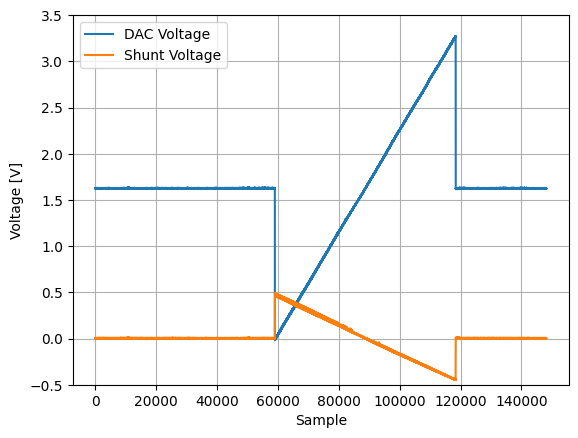

In [321]:
ax = data_1k_load.rename(columns={
    "dac_volts": "DAC Voltage",
    "shunt_volts": "Shunt Voltage",
}).plot(
    x="sample",
    y=["DAC Voltage", "Shunt Voltage"],
    grid=True,
    ylim=(-0.5, 3.5),
)

ax.set_xlabel("Sample")
ax.set_ylabel("Voltage [V]")


In [322]:
def extract_ramp_region(df, column, trigger_threshold, discarded_points=512):
    data = df.copy()
    diff = data[column].diff().abs()
    transition_points = diff[diff > trigger_threshold].index

    if len(transition_points) < 2:
        raise ValueError("Could not detect ramp start and end transitions.")

    start = transition_points[0] + discarded_points
    end = transition_points[-1] - discarded_points

    return data.loc[start:end].copy()


def equalize_sample_count(*dfs):
    sample_count = min(len(df) for df in dfs)
    aligned_dfs = []

    for df in dfs:
        aligned_df = df.iloc[:sample_count].reset_index(drop=True).copy()
        aligned_df["sample"] = aligned_df.index
        aligned_dfs.append(aligned_df)

    return aligned_dfs


In [323]:
data_1k_load = extract_ramp_region(data_1k_load, column="dac_volts", trigger_threshold=0.5)
data_2k_load = extract_ramp_region(data_2k_load, column="dac_volts", trigger_threshold=0.5)
data_4k7_load = extract_ramp_region(data_4k7_load, column="dac_volts", trigger_threshold=0.5)

data_1k_load, data_2k_load, data_4k7_load = equalize_sample_count(
    data_1k_load,
    data_2k_load,
    data_4k7_load,
)

ramp_sample_summary = pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "samples": [len(data_1k_load), len(data_2k_load), len(data_4k7_load)],
})

ramp_sample_summary


,load,samples
0,1k,58386
1,2k,58386
2,4k7,58386


## 4. Current Calculation

The output current was experimentally measured through the shunt channel. The current calculation below converts the measured shunt voltage into milliamps using Ohm's law.


Text(0, 0.5, 'Current [mA]')

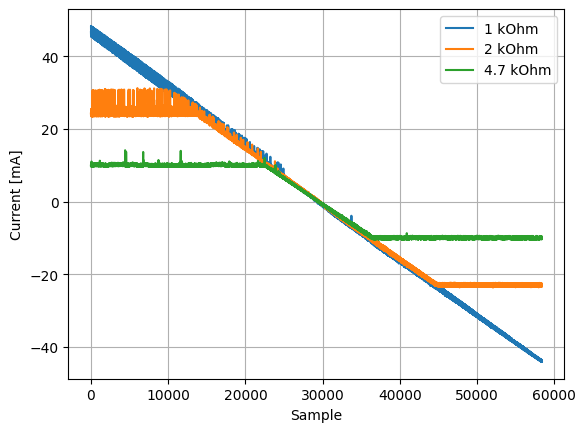

In [324]:
shunt_resistance_ohm = 10

for df in [data_1k_load, data_2k_load, data_4k7_load]:
    df["current_mA"] = (df["shunt_volts"] / shunt_resistance_ohm) * 1000

ax = data_1k_load.plot(
    x="sample",
    y="current_mA",
    grid=True,
    label="1 kOhm",
)
data_2k_load.plot(x="sample", y="current_mA", ax=ax, label="2 kOhm", grid=True)
data_4k7_load.plot(x="sample", y="current_mA", ax=ax, label="4.7 kOhm", grid=True)

ax.set_xlabel("Sample")
ax.set_ylabel("Current [mA]")


## 5. Data Binning / Aggregation

The DAC voltage is quantized into fixed-width bins before load comparison:

$$
V_{DAC,quantized} = \mathrm{round}\left(\frac{V_{DAC}}{\Delta V}\right) \cdot \Delta V
$$

where:

$$
\Delta V = 0.01\,V
$$

`processed_current_data` is the complete aggregated dataset and intentionally includes the compliance-limited regions. It must not be used for linearity modeling.


In [325]:
load_resistance_ohm = pd.Series({
    "1k": 1000,
    "2k": 2000,
    "4k7": 4700,
})

dac_step = 0.01

all_currents = pd.concat(
    [
        data_1k_load[["dac_volts", "current_mA"]].assign(load="1k"),
        data_2k_load[["dac_volts", "current_mA"]].assign(load="2k"),
        data_4k7_load[["dac_volts", "current_mA"]].assign(load="4k7"),
    ],
    ignore_index=True,
)

all_currents["dac_bin"] = ((all_currents["dac_volts"] / dac_step).round() * dac_step).round(2)

processed_current_data = all_currents.pivot_table(
    index="dac_bin",
    columns="load",
    values="current_mA",
    aggfunc="mean",
)

processed_current_data = processed_current_data[["1k", "2k", "4k7"]]
processed_current_data.head()


load,1k,2k,4k7
dac_bin,,,
0.01,45.9112215909091,24.1458821614583,9.91149114173228
0.02,46.3303842905405,24.31065625,9.932421875
0.03,46.1221478174603,24.4716610863095,9.95416666666667
0.04,45.878821997549,24.5200459558824,10.0818826687117
0.05,45.5565297067901,24.5200615284974,10.0743720095694


In [326]:
processed_current_data.tail()


load,1k,2k,4k7
dac_bin,,,
3.21,-43.0206953642384,-22.9546875,-10.0832514044944
3.22,-43.2675067204301,-22.9797514619883,-10.081411637931
3.23,-43.5159915123457,-22.9624384236453,-10.0842291666667
3.24,-43.7395720108696,-22.964898255814,-10.0065069901316
3.25,-43.803125,-23.1123697916667,-9.99872159090909


## 6. Full-Region EDA

The full region is important to characterize the complete experimental operating envelope, including saturation/compliance limits. However, it is not valid for DAC-current linearity conclusions because the saturated region reflects voltage compliance limitation rather than Howland source linearity failure.


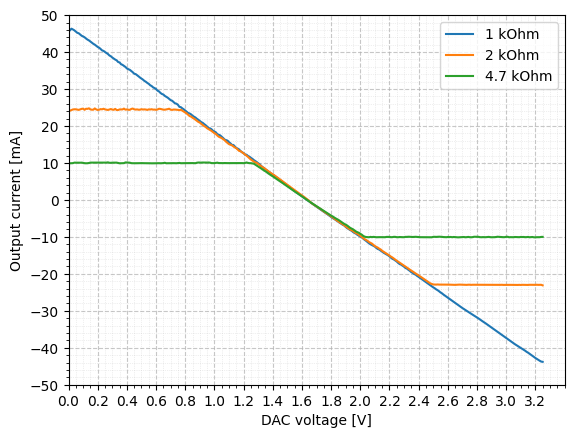

In [327]:
ax = processed_current_data.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.legend(["1 kOhm", "2 kOhm", "4.7 kOhm"])


In [328]:
full_region_stats = processed_current_data.describe().T
full_region_stats


,count,mean,std,min,25%,50%,75%,max
load,,,,,,,,
1k,325,0.788753485491859,26.4169142231993,-43.803125,-21.9626624381188,0.131057820855615,23.5196136934673,46.3303842905405
2k,325,0.649648967733633,19.1187390963475,-23.1123697916667,-21.5198206018519,0.34353813559322,23.0624479166667,24.7799053030303
4k7,325,0.0480396275364609,9.21466341437525,-10.1317881944444,-10.0271817396313,0.149336357526882,9.94859586148649,10.1651007401316


## 7. Linear Operating Region Selection

The saturated region is not treated as a linearity error. It is a compliance limitation of the output stage: once the required load voltage exceeds the available output voltage swing, the current can no longer follow the DAC command.

Because the FES output voltage was not measured directly, it is inferred from the measured current and load resistance:

$$
V_{load} = \frac{I_{out,mA}}{1000} \cdot R_{load}
$$

The common experimental compliance window is obtained from the measured minimum and maximum currents in `processed_current_data`. The most restrictive shared voltage interval is then applied to each load to create `linear_current_data`.


In [329]:
v_limits_rows = []

for load, resistance in load_resistance_ohm.items():
    i_min_mA = processed_current_data[load].min()
    i_max_mA = processed_current_data[load].max()

    v_limits_rows.append(
        {
            "load": load,
            "load_resistance_ohm": resistance,
            "i_min_mA": i_min_mA,
            "i_max_mA": i_max_mA,
            "v_min": (i_min_mA / 1000) * resistance,
            "v_max": (i_max_mA / 1000) * resistance,
        }
    )

v_limits = pd.DataFrame(v_limits_rows)

v_min_limit = v_limits["v_min"].max()
v_max_limit = v_limits["v_max"].min()

v_limits_summary = v_limits.copy()
v_limits_summary["common_v_min_limit"] = v_min_limit
v_limits_summary["common_v_max_limit"] = v_max_limit

v_limits_summary

,load,load_resistance_ohm,i_min_mA,i_max_mA,v_min,v_max,common_v_min_limit,common_v_max_limit
0,1k,1000,-43.803125,46.3303842905405,-43.803125,46.3303842905405,-43.803125,46.3303842905405
1,2k,2000,-23.1123697916667,24.7799053030303,-46.2247395833333,49.5598106060606,-43.803125,46.3303842905405
2,4k7,4700,-10.1317881944444,10.1651007401316,-47.6194045138889,47.7759734786184,-43.803125,46.3303842905405


In [330]:
linear_current_data = processed_current_data.copy()

for load, resistance in load_resistance_ohm.items():
    vload = (processed_current_data[load] / 1000) * resistance
    linear_current_data[load] = processed_current_data[load].where(
        (vload > v_min_limit) & (vload < v_max_limit)
    )

linear_region_summary = pd.DataFrame({
    "processed_points": processed_current_data.notna().sum(),
    "linear_points": linear_current_data.notna().sum(),
})

linear_region_summary["removed_points"] = (
    linear_region_summary["processed_points"] - linear_region_summary["linear_points"]
)
linear_region_summary["removed_percent"] = (
    100 * linear_region_summary["removed_points"] / linear_region_summary["processed_points"]
)

linear_region_summary


,processed_points,linear_points,removed_points,removed_percent
load,,,,
1k,325,323,2,0.615384615384615
2k,325,164,161,49.5384615384615
4k7,325,74,251,77.2307692307692


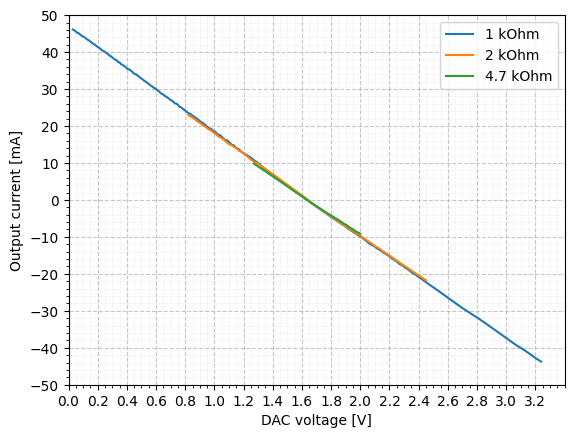

In [331]:
ax = linear_current_data.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.legend(["1 kOhm", "2 kOhm", "4.7 kOhm"])


## 8. Linear-Region Statistical Analysis

`full_region_stats` characterizes the complete experimental response, including compliance limits. `linear_region_stats` characterizes only the region where the Howland current source is within compliance and is therefore the correct dataset for linearity analysis.


In [332]:
linear_region_stats = linear_current_data.describe().T
linear_region_stats


,count,mean,std,min,25%,50%,75%,max
load,,,,,,,,
1k,323,0.785813075833789,26.259692628555,-43.7395720108696,-21.8162304789278,0.131057820855615,23.4542826233609,46.1221478174603
2k,164,0.401193078517914,13.1215360013253,-21.7568055555556,-10.9163452260152,0.204406600348694,11.7498666616587,23.0624479166667
4k7,74,0.147855655833489,5.63663409276725,-9.16850806451613,-4.65635717353952,0.00732921192670616,4.97293433965403,9.81203981164384


In [333]:
linear_long = (
    linear_current_data
    .reset_index()
    .melt(id_vars="dac_bin", var_name="load", value_name="current_mA")
    .dropna()
    .reset_index(drop=True)
)


In [334]:
linear_long.head()

,dac_bin,load,current_mA
0,0.01,1k,45.9112215909091
1,0.03,1k,46.1221478174603
2,0.04,1k,45.878821997549
3,0.05,1k,45.5565297067901
4,0.06,1k,45.2190145502645


In [335]:
linear_long.tail()

,dac_bin,load,current_mA
556,1.96,4k7,-8.24177587365591
557,1.97,4k7,-8.53251753826531
558,1.98,4k7,-8.73402493169399
559,1.99,4k7,-8.89386853448276
560,2,4k7,-9.16850806451613


## 9. Correlation Analysis

Pearson and Spearman correlations are computed per load using only `linear_long`, which is derived from `linear_current_data`. The compliance-limited region is excluded, so these correlations are suitable for discussing DAC-current linearity.

Values close to -1 indicate a strong inverse linear/monotonic relationship: the measured current decreases as DAC voltage increases.


In [336]:

def compute_correlation_summary(df, dataset_name):
    rows = []

    for load, group in df.groupby("load"):
        x = group["dac_bin"]
        y = group["current_mA"]
        samples = len(group)

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_r, spearman_p = spearmanr(x, y)

        rows.append({
            "dataset": dataset_name,
            "load": load,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
            "samples": samples,
        })

    return pd.DataFrame(rows)


correlation_summary = compute_correlation_summary(linear_long, "linear_region")
correlation_summary


,dataset,load,pearson_r,pearson_p,spearman_r,spearman_p,samples
0,linear_region,1k,-0.999909252907146,0,-0.999999643895188,0,323
1,linear_region,2k,-0.999899428482331,2.39161611552458e-301,-1,0,164
2,linear_region,4k7,-0.999823865633471,4.54915652292629e-126,-1,0,74


## 10. Regression Models

All regression models below use only `linear_long`, because this dataset excludes the compliance-limited region. The per-load regressions characterize how each resistive load behaves inside the valid operating region.


In [337]:
def regression_metrics(x, y):
    result = linregress(x, y)
    y_pred = result.slope * x + result.intercept
    residual = y - y_pred

    return {
        "slope_mA_per_V": result.slope,
        "intercept_mA": result.intercept,
        "r_value": result.rvalue,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "slope_std_error": result.stderr,
        "MAE_mA": residual.abs().mean(),
        "RMSE_mA": (residual ** 2).mean() ** 0.5,
        "max_abs_error_mA": residual.abs().max(),
        "samples": len(x),
    }


regression_rows = []

for load, group in linear_long.groupby("load"):
    metrics = regression_metrics(group["dac_bin"], group["current_mA"])
    metrics["load"] = load
    regression_rows.append(metrics)

regression_by_load_summary = pd.DataFrame(regression_rows)[[
    "load",
    "slope_mA_per_V",
    "intercept_mA",
    "r_value",
    "r_squared",
    "p_value",
    "slope_std_error",
    "MAE_mA",
    "RMSE_mA",
    "max_abs_error_mA",
    "samples",
]]

regression_by_load_summary


,load,slope_mA_per_V,intercept_mA,r_value,r_squared,p_value,slope_std_error,MAE_mA,RMSE_mA,max_abs_error_mA,samples
0,1k,-28.1152602119382,46.6128167798005,-0.999909252907146,0.999818514049327,0,0.0211422161832474,0.287826700520108,0.353213926343742,0.741054296009828,323
1,2k,-27.6291626701812,45.5748740442642,-0.999899428482331,0.999798867079293,2.39161611488317e-301,0.0307889923729929,0.153489726830905,0.18552316068555,0.420580410629754,164
2,4k7,-26.2051997005197,42.9933571661832,-0.999823865633471,0.999647762290257,4.5491565226166e-126,0.0579716485552685,0.0917722794621639,0.105071114198935,0.261121703368257,74


### Global Linear Model

A single global linear model is estimated using all available loads inside the selected linear compliance region: 1 kOhm, 2 kOhm, and 4.7 kOhm. This keeps the characterization model tied to the full experimental dataset after compliance-limited points have been removed.


In [338]:
def fit_linear_model_summary(df, model_name):
    x = df[["dac_bin"]]
    y = df["current_mA"]

    model = LinearRegression()
    model.fit(x, y)

    y_pred = pd.Series(model.predict(x), index=df.index)
    residual = y - y_pred

    return model, pd.DataFrame([{
        "model": model_name,
        "slope_mA_per_V": model.coef_[0],
        "intercept_mA": model.intercept_,
        "MAE_mA": mean_absolute_error(y, y_pred),
        "RMSE_mA": mean_squared_error(y, y_pred) ** 0.5,
        "R2": r2_score(y, y_pred),
        "max_abs_error_mA": residual.abs().max(),
        "samples": len(df),
    }])


global_model, global_model_summary = fit_linear_model_summary(
    linear_long,
    "global_linear_model_all_loads",
)

a_global = global_model_summary.loc[0, "slope_mA_per_V"]
b_global = global_model_summary.loc[0, "intercept_mA"]

global_model_summary


,model,slope_mA_per_V,intercept_mA,MAE_mA,RMSE_mA,R2,max_abs_error_mA,samples
0,global_linear_model_all_loads,-28.0401970084357,46.3537244024897,0.328845208351965,0.385635196184521,0.999669534467608,0.930634390132553,561


In [339]:
global_model_summary


,model,slope_mA_per_V,intercept_mA,MAE_mA,RMSE_mA,R2,max_abs_error_mA,samples
0,global_linear_model_all_loads,-28.0401970084357,46.3537244024897,0.328845208351965,0.385635196184521,0.999669534467608,0.930634390132553,561


### MCU Open-Loop DAC Estimation Model

The selected open-loop DAC estimation model uses all loads available in the linear compliance region:

$$
I_{out,mA} = a \cdot V_{DAC} + b
$$

The inverse model to be implemented in firmware is:

$$
V_{DAC} = \frac{I_{target,mA} - b}{a}
$$

This inverse model is valid only inside the experimentally selected compliance region.


In [340]:
print(f"Iout_mA = {a_global:.8f} * Vdac + {b_global:.8f}")
print(f"Vdac = (I_target_mA - ({b_global:.8f})) / {a_global:.8f}")


Iout_mA = -28.04019701 * Vdac + 46.35372440
Vdac = (I_target_mA - (46.35372440)) / -28.04019701


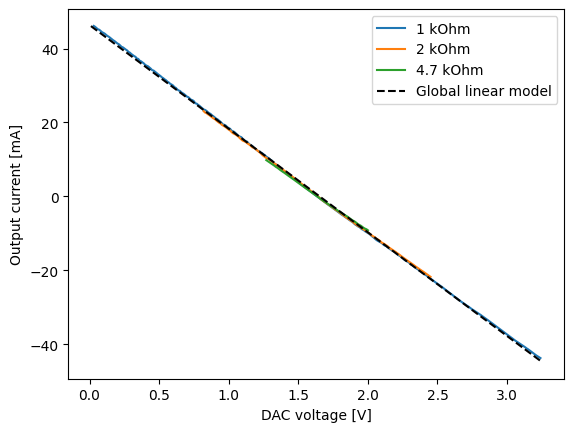

In [341]:
# =========================================================
# Experimental current and global model
# =========================================================

model_curve = pd.DataFrame(index=linear_current_data.index)
model_curve["global_model"] = a_global * model_curve.index + b_global

ax = linear_current_data.plot(
    grid=True,
)

model_curve["global_model"].plot(
    ax=ax,
    linestyle="--",
    color="black",
    label="Global linear model",
)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.legend(["1 kOhm", "2 kOhm", "4.7 kOhm", "Global linear model"])


## 11. Consistency Between Loads

Inside the linear operating region, the output current should ideally be independent of the load resistance. The spread between 1 kOhm and 2 kOhm is the strongest consistency metric because these loads have the largest shared useful range before compliance limitation. The 4.7 kOhm load remains important but must be discussed separately because it reaches compliance earlier.


In [342]:
current_spread_data = linear_current_data.copy()

current_spread_data["spread_1k_2k_mA"] = (current_spread_data["1k"] - current_spread_data["2k"]).abs()
current_spread_data["spread_1k_4k7_mA"] = (current_spread_data["1k"] - current_spread_data["4k7"]).abs()
current_spread_data["spread_2k_4k7_mA"] = (current_spread_data["2k"] - current_spread_data["4k7"]).abs()

consistency_summary = current_spread_data[[
    "spread_1k_2k_mA",
    "spread_1k_4k7_mA",
    "spread_2k_4k7_mA",
]].describe().T

consistency_summary


,count,mean,std,min,25%,50%,75%,max
load,,,,,,,,
spread_1k_2k_mA,164,0.259076604903301,0.156087398775021,0.00379368929823265,0.134991510383154,0.223598902999345,0.38258990655802,0.7027368355125
spread_1k_4k7_mA,74,0.389652283866224,0.263358173696132,0.00294004826671601,0.173668454998048,0.39550307448648,0.57095647420161,0.972149706047032
spread_2k_4k7_mA,74,0.381751440783685,0.187332501930732,0.0122121320778249,0.237944643412402,0.404291773348064,0.543318011560926,0.730447056303911


Text(0, 0.5, 'Absolute current difference [mA]')

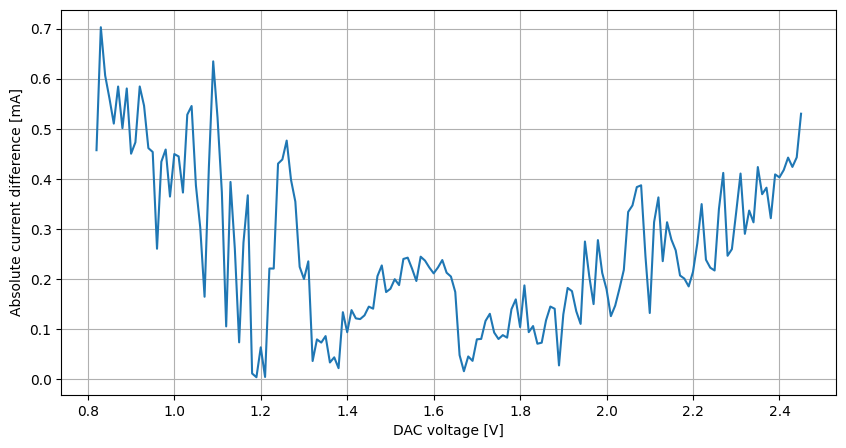

In [343]:
ax = current_spread_data["spread_1k_2k_mA"].plot(
    figsize=(10, 5),
    grid=True,
)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Absolute current difference [mA]")


## 12. Residual Analysis

Residuals are computed for the global model fitted with all loads in the linear compliance region. A visible residual trend versus DAC may indicate offset, asymmetry, small nonlinearity, measurement effects, or operation close to compliance.


In [344]:
global_model_data = linear_long.copy()
global_model_data["current_pred_mA"] = global_model.predict(global_model_data[["dac_bin"]])
global_model_data["residual_mA"] = global_model_data["current_mA"] - global_model_data["current_pred_mA"]

residual_summary = pd.DataFrame({
    "mean": [global_model_data["residual_mA"].mean()],
    "std": [global_model_data["residual_mA"].std()],
    "min": [global_model_data["residual_mA"].min()],
    "max": [global_model_data["residual_mA"].max()],
    "MAE": [global_model_data["residual_mA"].abs().mean()],
    "RMSE": [(global_model_data["residual_mA"] ** 2).mean() ** 0.5],
})

residual_summary


,mean,std,min,max,MAE,RMSE
0,-1.48188057190609e-15,0.385979359748054,-0.930634390132553,0.756941893972339,0.328845208351965,0.385635196184521


Text(0, 0.5, 'Residual [mA]')

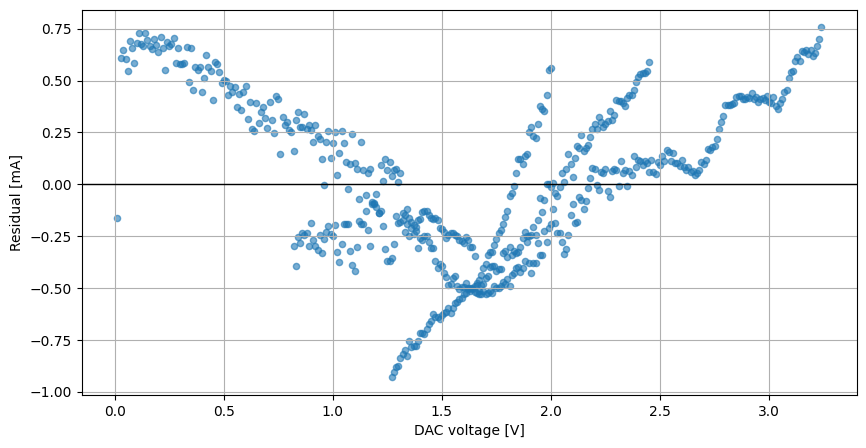

In [345]:
ax = global_model_data.plot(
    x="dac_bin",
    y="residual_mA",
    kind="scatter",
    figsize=(10, 5),
    grid=True,
    alpha=0.6,
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Residual [mA]")


If the residual plot shows a systematic trend, it should be discussed as possible evidence of asymmetry, offset, small nonlinear effects, measurement uncertainty, or operation close to the compliance boundary.


## 13. Cross-Validation

KFold cross-validation is applied to the global model dataset, using all loads in the selected linear compliance region. Leave-One-Group-Out by load is also included as an optional stress test: it evaluates how well the model generalizes to a load not seen during fitting.


In [346]:
X = global_model_data[["dac_bin"]]
y = global_model_data["current_mA"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for fold, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cv_rows.append({
        "fold": fold,
        "RMSE_mA": mean_squared_error(y_test, y_pred) ** 0.5,
        "R2": r2_score(y_test, y_pred),
    })

cross_validation_folds = pd.DataFrame(cv_rows)

cross_validation_summary = pd.DataFrame({
    "RMSE_mean_mA": [cross_validation_folds["RMSE_mA"].mean()],
    "RMSE_std_mA": [cross_validation_folds["RMSE_mA"].std()],
    "R2_mean": [cross_validation_folds["R2"].mean()],
    "R2_std": [cross_validation_folds["R2"].std()],
})

cross_validation_summary


,RMSE_mean_mA,RMSE_std_mA,R2_mean,R2_std
0,0.385602139614591,0.038864679778318,0.999665467931043,2.88695972761805e-05


In [347]:
logo = LeaveOneGroupOut()
logo_rows = []

groups = global_model_data["load"]

for train_index, test_index in logo.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    test_load = groups.iloc[test_index].unique()[0]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    logo_rows.append({
        "test_load": test_load,
        "RMSE_mA": mean_squared_error(y_test, y_pred) ** 0.5,
        "R2": r2_score(y_test, y_pred),
        "samples": len(test_index),
    })

logo_summary = pd.DataFrame(logo_rows)
logo_summary


,test_load,RMSE_mA,R2,samples
0,1k,0.741333900851802,0.999200543026229,323
1,2k,0.324613917025081,0.999384226264081,164
2,4k7,0.583069646559276,0.989152990003555,74


## 14. Discussion-Ready Summaries

The tables below collect the main results needed for reporting.


In [348]:
summary_tables = {
    "v_limits_summary": v_limits_summary,
    "linear_region_summary": linear_region_summary,
    "full_region_stats": full_region_stats,
    "linear_region_stats": linear_region_stats,
    "correlation_summary": correlation_summary,
    "regression_by_load_summary": regression_by_load_summary,
    "global_model_summary": global_model_summary,
    "consistency_summary": consistency_summary,
    "residual_summary": residual_summary,
    "cross_validation_summary": cross_validation_summary,
    "logo_summary": logo_summary,
}

summary_tables.keys()


dict_keys(['v_limits_summary', 'linear_region_summary', 'full_region_stats', 'linear_region_stats', 'correlation_summary', 'regression_by_load_summary', 'global_model_summary', 'consistency_summary', 'residual_summary', 'cross_validation_summary', 'logo_summary'])

## Technical Conclusion

Within the experimentally selected compliance region, the DAC-to-current relationship should be interpreted using `linear_current_data` only. The saturated portions observed in `processed_current_data` are not evidence of Howland current-source nonlinearity; they are a consequence of the output compliance limit imposed by the available voltage swing of the FES power stage.

The complete dataset remains important because it documents the operating limits of the hardware. However, regression, Pearson/Spearman linearity analysis, residual analysis, and the MCU DAC estimation model are based exclusively on the compliance-valid region.

Because there is no real-time current feedback to the MCU, the inverse model:

$$
V_{DAC} = \frac{I_{target,mA} - b}{a}
$$

is an open-loop DAC estimation equation. It is valid only while the load remains inside the compliance region. In real use, increased skin impedance, poor electrode contact, or electrode-skin interface variation can force the output stage into compliance without firmware detection unless current measurement is added in closed loop.

The recommended model is the global linear model fitted with all loads available in the selected linear compliance region. The 4.7 kOhm load remains part of the model and the characterization, while its earlier compliance limitation is documented by the linear-region selection and should be discussed as part of the operating envelope.
